In [23]:
# Week 3: Predicting Participants-Rated Visual Complexity
# This section loads the extracted image features and participant-rated visual complexity scores. The goal is to predict human perception of visual complexity using computational image features.

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

from scipy.stats import pearsonr

df = pd.read_csv("features.csv")

df.head()

,image,category,edge_density,brightness,color_var,researcher_complexity,participant_complexity
0,messydesk7.jpg,messydesk,0.077890,101.136589,4335.570978,3,3.0
1,messydesk6.jpg,messydesk,0.137203,104.760084,6056.457666,4,3.8
2,messydesk4.jpg,messydesk,0.210503,100.931705,5855.070950,4,3.6
3,messydesk5.jpg,messydesk,0.210233,151.360417,3667.823877,5,4.4
4,messydesk20.jpg,messydesk,0.125405,148.425892,6162.957314,3,3.6


In [24]:
#Three image features are used as predictors: Edge density: amount of visual structure, Brightness: average image intensity, Color variation: RGB variability

X = df[
    [
        "edge_density",
        "brightness",
        "color_var"
    ]
]

y = df["participant_complexity"]

In [25]:
#The dataset is split into training and testing sets to evaluate how well models generalize to unseen images.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
#Two regression models are compared: Linear Regression: tests whether image features have approximately linear relationships with perceived complexity. Random Forest: tests whether nonlinear relationships improve prediction.

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [27]:
#Model performance is evaluated using R² and Mean Squared Error (MSE).

linear_pred = linear_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

In [28]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "R²":[
        r2_score(y_test, linear_pred),
        r2_score(y_test, rf_pred)
    ],

    "MSE":[
        mean_squared_error(y_test, linear_pred),
        mean_squared_error(y_test, rf_pred)
    ]

})

comparison

,Model,R²,MSE
0,Linear Regression,0.324746,0.296162
1,Random Forest,-0.093286,0.479509


In [29]:
#The trained linear model is used to generate predicted complexity scores for all images. These predictions are compared with human ratings.

df["AI_prediction"] = linear_model.predict(X)

df.head()

,image,category,edge_density,brightness,color_var,researcher_complexity,participant_complexity,AI_prediction
0,messydesk7.jpg,messydesk,0.077890,101.136589,4335.570978,3,3.0,2.789125
1,messydesk6.jpg,messydesk,0.137203,104.760084,6056.457666,4,3.8,3.486407
2,messydesk4.jpg,messydesk,0.210503,100.931705,5855.070950,4,3.6,3.918625
3,messydesk5.jpg,messydesk,0.210233,151.360417,3667.823877,5,4.4,3.160668
4,messydesk20.jpg,messydesk,0.125405,148.425892,6162.957314,3,3.6,3.171306


In [30]:
correlation, p_value = pearsonr(
    df["participant_complexity"],
    df["AI_prediction"]
)

print("Correlation:", correlation)
print("p-value:", p_value)

Correlation: 0.6506117471399031
p-value: 6.475041564566138e-11


In [31]:
#Feature importance analysis identifies which visual characteristics contribute most to prediction.

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,edge_density,0.577840
1,brightness,0.247688
2,color_var,0.174472


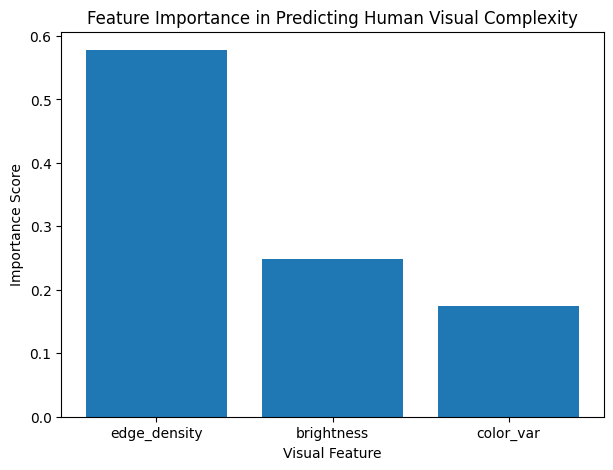

In [32]:
plt.figure(figsize=(7,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Visual Feature")
plt.ylabel("Importance Score")

plt.title(
    "Feature Importance in Predicting Human Visual Complexity"
)

plt.show()

In [33]:
individual_features = [
    "edge_density",
    "brightness",
    "color_var"
]

for feature in individual_features:
    
    correlation, p_value = pearsonr(
        df[feature],
        df["participant_complexity"]
    )
    
    print(feature)
    print("Correlation:", correlation)
    print("p-value:", p_value)
    print()

edge_density
Correlation: 0.5697770683983715
p-value: 3.4663384559889963e-08

brightness
Correlation: -0.3562617584889941
p-value: 0.001180811884568787

color_var
Correlation: 0.3649743929151943
p-value: 0.0008726196910988271



In [35]:
feature_sets = {
    "All features": [
        "edge_density",
        "brightness",
        "color_var"
    ],
    
    "Edge density only": [
        "edge_density"
    ],
    
    "Brightness only": [
        "brightness"
    ],
    
    "Color variance only": [
        "color_var"
    ]
}


results = []


for name, features in feature_sets.items():
    
    X_feature = df[features]

    X_train, X_test, y_train, y_test = train_test_split(
    X_feature,
    y,
    test_size=0.2,
    random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    
    results.append({
        "Features Used": name,
        "R²": r2
    })


comparison = pd.DataFrame(results)

comparison.sort_values(
    "R²",
    ascending=False
)

,Features Used,R²
0,All features,0.324746
1,Edge density only,0.255168
2,Brightness only,-0.037913
3,Color variance only,-0.276941


In [15]:
df["error"] = abs(
    df["participant_complexity"] -
    df["AI_prediction"]
)

df.sort_values(
    "error",
    ascending=False
).head(10)

,image,category,edge_density,brightness,color_var,researcher_complexity,participant_complexity,AI_prediction,error
9,messydesk3.jpg,messydesk,0.026010,97.022169,3650.593171,2,4.0,2.354004,1.645996
74,simpleroom1.jpg,simpleroom,0.045043,186.286591,1201.324062,2,2.8,1.425416,1.374584
25,streets1.jpg,streets,0.064613,103.202655,5094.818702,3,4.2,2.851485,1.348515
49,landscape9.jpg,landscape,0.225077,115.640755,4894.134663,4,2.4,3.721041,1.321041
24,streets2.jpg,streets,0.009289,64.864223,2884.278008,3,3.6,2.288110,1.311890
26,streets5.jpg,streets,0.066771,155.987420,3949.653813,4,3.6,2.308949,1.291051
44,landscape15.jpg,landscape,0.123100,156.945951,3171.224116,3,1.2,2.488926,1.288926
3,messydesk5.jpg,messydesk,0.210233,151.360417,3667.823877,5,4.4,3.160668,1.239332
55,landscape7.jpg,landscape,0.151913,69.194019,3836.390050,5,2.2,3.334728,1.134728
6,messydesk1.jpg,messydesk,0.188773,142.322364,4699.517528,4,4.4,3.296153,1.103847


In [16]:
corr, p = pearsonr(
    df["researcher_complexity"],
    df["participant_complexity"]
)

print("Researcher vs Participant Correlation:", corr)
print("p-value:", p)

Researcher vs Participant Correlation: 0.60542490151243
p-value: 2.6950939442083457e-09


In [17]:
df["rating_difference"] = (
    df["researcher_complexity"]
    - df["participant_complexity"]
)

print(df["rating_difference"].describe())

count    80.000000
mean      0.487500
std       0.833382
min      -2.000000
25%       0.000000
50%       0.400000
75%       1.000000
max       2.800000
Name: rating_difference, dtype: float64


In [18]:
df.reindex(
    df["rating_difference"].abs().sort_values(
        ascending=False
    ).index
).head(10)

,image,category,edge_density,brightness,color_var,researcher_complexity,participant_complexity,AI_prediction,error,rating_difference
55,landscape7.jpg,landscape,0.151913,69.194019,3836.390050,5,2.2,3.334728,1.134728,2.8
56,landscape6.jpg,landscape,0.173154,68.817864,3459.930433,5,2.4,3.389979,0.989979,2.6
73,simpleroom11.jpg,simpleroom,0.077561,101.783407,2692.551174,4,2.0,2.444561,0.444561,2.0
9,messydesk3.jpg,messydesk,0.026010,97.022169,3650.593171,2,4.0,2.354004,1.645996,-2.0
44,landscape15.jpg,landscape,0.123100,156.945951,3171.224116,3,1.2,2.488926,1.288926,1.8
13,messydesk15.jpg,messydesk,0.158847,104.824898,5533.172899,5,3.4,3.511201,0.111201,1.6
47,landscape17.jpg,landscape,0.204962,89.984476,2905.840308,5,3.4,3.343051,0.056949,1.6
49,landscape9.jpg,landscape,0.225077,115.640755,4894.134663,4,2.4,3.721041,1.321041,1.6
69,simpleroom13.jpg,simpleroom,0.010618,144.458773,3236.473766,3,1.4,1.886670,0.486670,1.6
79,simpleroom8.jpg,simpleroom,0.114536,177.608306,3564.579618,3,1.6,2.392181,0.792181,1.4


In [19]:
category_summary = df.groupby("category")[
    "participant_complexity"
].mean()

print(category_summary)

category
landscape     2.46
messydesk     3.63
simpleroom    2.16
streets       3.90
Name: participant_complexity, dtype: float64


In [20]:
df.groupby("category")[[
    "participant_complexity",
    "AI_prediction"
]].mean()

,participant_complexity,AI_prediction
category,,
landscape,2.46,3.148447
messydesk,3.63,3.124291
simpleroom,2.16,2.328980
streets,3.90,3.430643


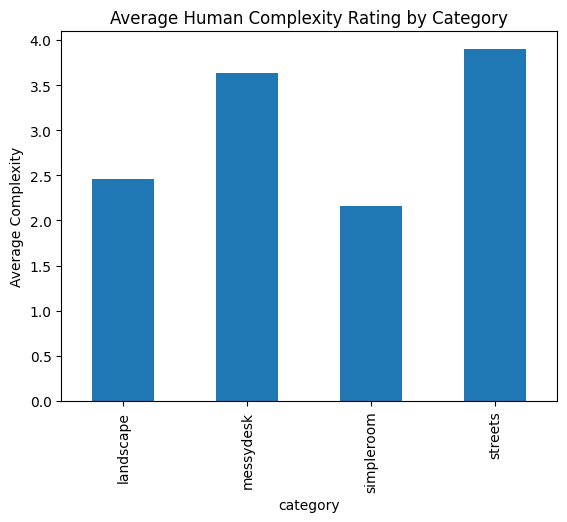

In [21]:
import matplotlib.pyplot as plt

category_summary.plot(
    kind="bar"
)

plt.ylabel("Average Complexity")

plt.title("Average Human Complexity Rating by Category")

plt.show()

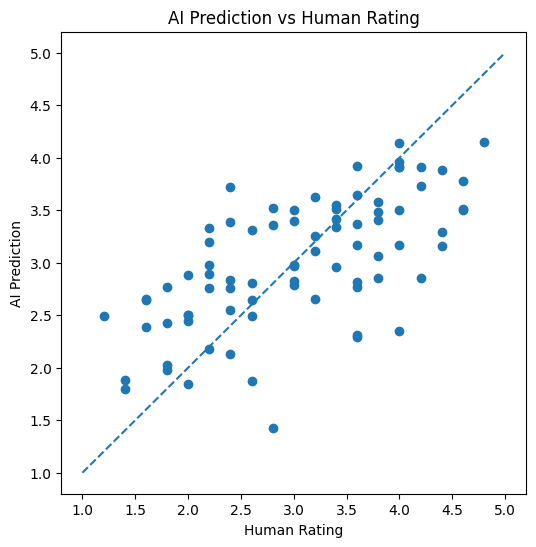

In [36]:
plt.figure(figsize=(6,6))

plt.scatter(
    df["participant_complexity"],
    df["AI_prediction"]
)

plt.xlabel("Human Rating")

plt.ylabel("AI Prediction")

plt.title("AI Prediction vs Human Rating")

plt.plot(
    [1,5],
    [1,5],
    "--"
)

plt.show()

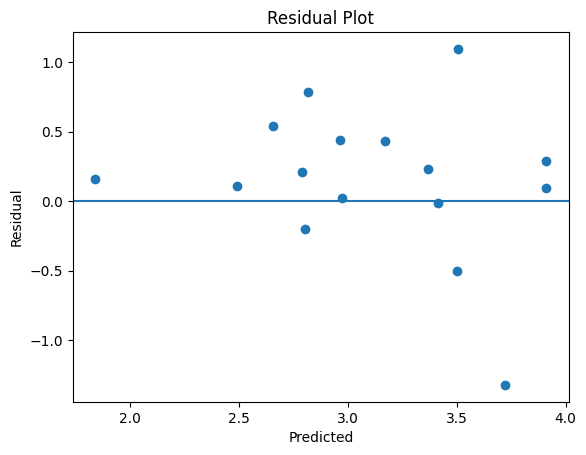

In [37]:
residuals = y_test - linear_pred

plt.scatter(linear_pred, residuals)

plt.axhline(0)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()